In [1]:
# ── Cell 1 : Setup & Imports ──────────
import json
import pickle
import pathlib
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

project_root = next(
    p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
    if (p / "pyproject.toml").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src import marginal_comparison as mc

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (15, 4)
print("Imports successful!")

Imports successful!


In [2]:
# ── Cell 2 : Locate Sibling Sampler Runs ──────────
# This notebook sits in a <chains>/<k>_comp/ folder and compares the NUTS, HMC and
# bayesm runs that live beside it: <sampler>/<run>/results/posterior_raw.pkl.

def _resolve_dir():
    nb = globals().get("__vsc_ipynb_file__")
    return pathlib.Path(nb).resolve().parent if nb else pathlib.Path.cwd()

XCOMP_DIR = _resolve_dir()
hits = sorted(XCOMP_DIR.glob("*/*/results/posterior_raw.pkl"))
if not hits:
    raise FileNotFoundError(
        f"No <sampler>/<run>/results/posterior_raw.pkl under:\n  {XCOMP_DIR}\n"
        f"This notebook must sit in a <chains>/<k>_comp/ folder. In VS Code set\n"
        f'  "jupyter.notebookFileRoot": "${{fileDirname}}"  and restart the kernel.'
    )

runs = {}
for h in hits:
    sampler = h.parents[2].name          # NUTS / HMC / bayesm
    runs.setdefault(sampler, h.parent)   # first run's results dir per sampler

meta = json.load(open(next(iter(runs.values())) / "meta.json"))
SCENARIO = meta["scenario"]
K_MODEL  = int(meta["k_model"])
K_TRUE   = int(meta["k_true"])
CHAINS   = int(meta["chains"])

print(f"x_comp folder : {XCOMP_DIR}")
print(f"scenario={SCENARIO}  K_MODEL={K_MODEL}  K_TRUE={K_TRUE}")
print(f"samplers found: {list(runs)}")

models = [mc.load_sampler(rd, name) for name, rd in runs.items()]
for m in models:
    print(f"  {m['name']:<8} mu {m['mu'].shape}")

x_comp folder : C:\Users\ThinkPad\Desktop\Repositories\HierarchicalBayesianMultinomialLogit\hbmnl_mixture_experiments\2_chains\2_comp
scenario=2comp_equal  K_MODEL=5  K_TRUE=2
samplers found: ['bayesm', 'HMC', 'NUTS', 'replication']


  bayesm   mu (2, 10000, 5, 4)
  HMC      mu (2, 10000, 5, 4)
  NUTS     mu (2, 10000, 5, 4)
  replication mu (2, 10000, 5, 4)


In [3]:
# ── Cell 3 : Ground Truth & Grids (Full, unbounded  +  Chebyshev-filtered) ──────────
# Two grids are built per parameter and carried through every cell below. Neither
# uses the True DGP to set bounds beyond including it in the envelope/moments -
# it stays an overlay only.
#   "Full"                   - mc.build_grids_full: raw min/max envelope over EVERY
#                               component (all K, incl. surplus/empty ones) of every
#                               sampler and the True DGP. Nothing is excluded, so every
#                               metric integrates over the ENTIRE marginal - but a
#                               diffuse empty component (K_MODEL > K_TRUE) or a sampler
#                               exploring far off the high-density area can stretch this
#                               range enormously and squash the real mass into a few
#                               pixels.
#   "Chebyshev (k=5, >=96%)" - mc.build_grids_chebyshev: clipped to each model's own
#                               AGGREGATE mixture [mean - 5*std, mean + 5*std] (Eq.
#                               5.5.2). Chebyshev's inequality, P(|X-mean|>=k*std) <=
#                               1/k**2, holds for ANY distribution with finite variance
#                               (no normality/unimodality assumption - the invariant
#                               marginal is itself a mixture) - so >=1 - 1/5**2 = 96% of
#                               each model's own marginal mass is guaranteed to lie
#                               inside its window, trimming the outlier-driven tails of
#                               "Full" while keeping a distribution-free coverage bound.
raw = json.load(open(project_root / "data" / "simulated" / "mixture" / f"{SCENARIO}.json"))
P = int(raw["n_params"])
param_names = raw.get("param_names") or [f"Param_{i}" for i in range(P)]
true_model = mc.true_dgp_model(raw)

GRIDS = {
    "Full":                  mc.build_grids_full(models, true_model, n_grid=1000, n_sigma=6),
    "Chebyshev (k=5, >=96%)": mc.build_grids_chebyshev(models, true_model, n_grid=1000, k=5.0),
}
for label, grids in GRIDS.items():
    print(f"Grid extents [{label}]:")
    for j, pj in enumerate(param_names):
        print(f"  {pj:<10} [{grids[j][0]:+.2f}, {grids[j][-1]:+.2f}]")

Grid extents [Full]:
  Alt1       [-4769.54, +5069.24]
  Alt2       [-1495.26, +1044.47]
  Alt3       [-468.47, +498.61]
  Price      [-452.79, +389.68]
Grid extents [Chebyshev (k=5, >=96%)]:
  Alt1       [-15.68, +20.15]
  Alt2       [-21.96, +23.81]
  Alt3       [-8.33, +12.81]
  Price      [-20.52, +10.63]


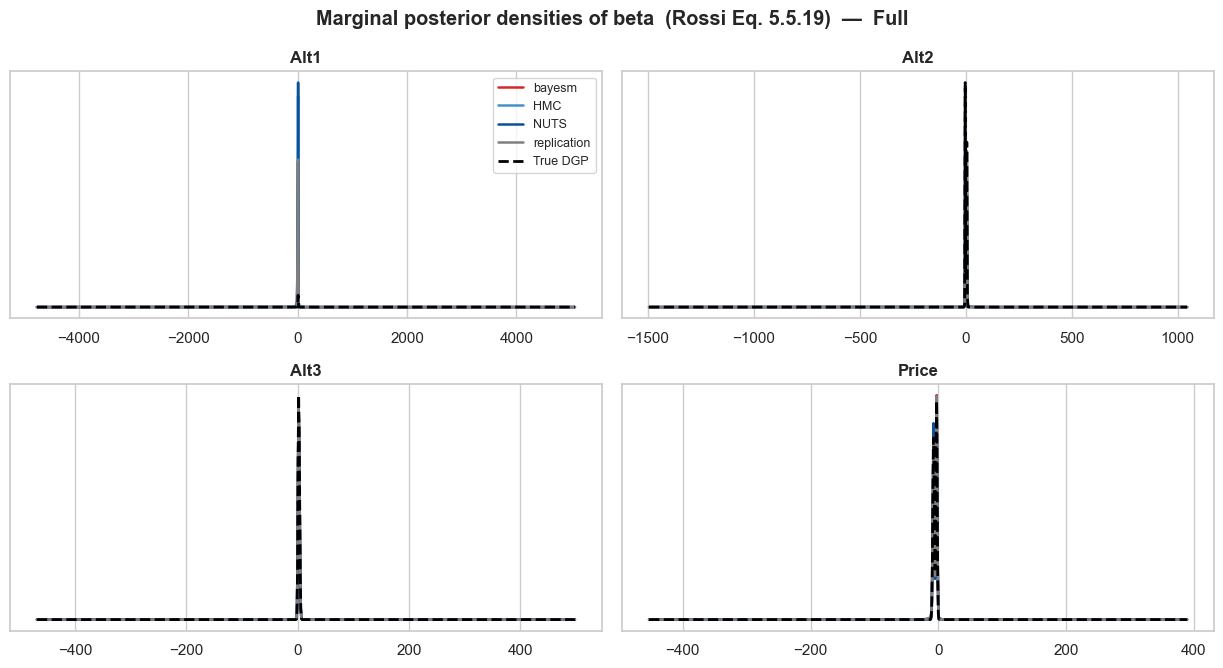

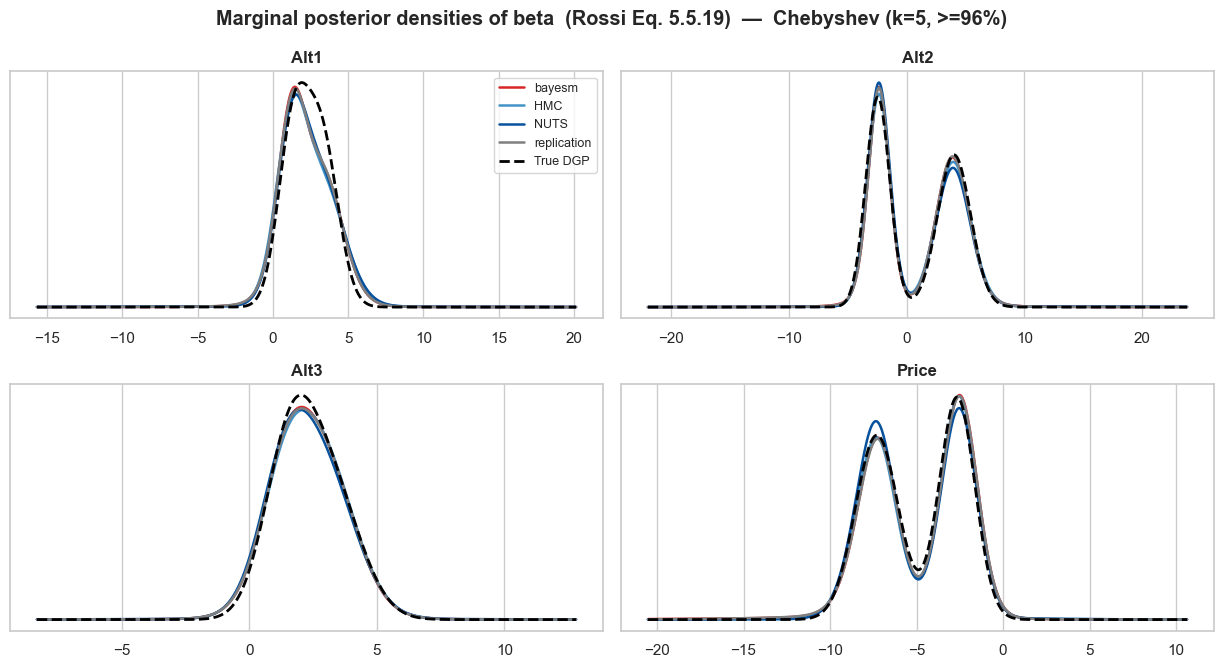

In [4]:
# ── Cell 4 : Marginal Densities (Rossi Eq. 5.5.19) - Full vs Chebyshev-filtered ──────────
# True DGP = black (dashed reference), bayesm = red, Liesel samplers = distinct
# shades of blue (ColorBrewer Blues: dark -> light). One figure per grid pass.
# `marginal_density` is O(R*K*n_grid) per model - computed ONCE per (model, grid)
# pass here and cached in DENS/DENS_TRUE so Cells 5 and 7 reuse it instead of
# recomputing it internally.
colors = {"NUTS": "#08519c", "HMC": "#4292c6", "iwls": "#9ecae1", "bayesm": "#d62728"}
TRUE_COLOR = "#000000"
ncols = min(P, 2)
nrows = int(np.ceil(P / ncols))

DENS, DENS_TRUE = {}, {}
for label, grids in GRIDS.items():
    dens      = {m["name"]: mc.marginal_density(m, grids) for m in models}
    dens_true = mc.marginal_density(true_model, grids)
    DENS[label], DENS_TRUE[label] = dens, dens_true

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6.2, nrows * 3.4), squeeze=False)
    ax = axes.ravel()
    for j, pj in enumerate(param_names):
        for name, d in dens.items():
            ax[j].plot(grids[j], d[j], lw=1.8, label=name, color=colors.get(name, "#7f7f7f"))
        ax[j].plot(grids[j], dens_true[j], lw=2.0, ls="--", color=TRUE_COLOR, label="True DGP")
        ax[j].set_title(pj, fontweight="bold")
        ax[j].set_yticks([])
    for j in range(P, len(ax)):
        ax[j].set_visible(False)
    ax[0].legend(fontsize=9)
    fig.suptitle(f"Marginal posterior densities of beta  (Rossi Eq. 5.5.19)  \u2014  {label}",
                 fontweight="bold")
    fig.tight_layout()
    plt.show()

In [5]:
# ── Cell 5 : Density Distances vs True DGP - Full vs Chebyshev-filtered ──────────
# Every sampler's marginal is compared ONLY to the True DGP marginal (never to
# another sampler). Metrics: Hellinger (primary), KL(model||true), Jensen-Shannon,
# total-variation, Wasserstein-1. All label-invariant - relabeling/ECR would not
# change them. The two passes differ only in the integration grid built in Cell 3;
# distances typically shrink under "Chebyshev" once the diffuse/outlier tails that
# dominate "Full" are clipped out. Reuses the densities cached in Cell 4 (DENS,
# DENS_TRUE) rather than recomputing marginal_density a second time.
for label, grids in GRIDS.items():
    print(f"--- {label} ---")
    display(mc.distance_table(models, true_model, grids, param_names,
                               dens=DENS[label], dens_true=DENS_TRUE[label]))

--- Full ---


C:\Users\ThinkPad\Desktop\Repositories\HierarchicalBayesianMultinomialLogit\src\marginal_comparison.py:222: RuntimeWarning: overflow encountered in divide
  term = np.where((a > 0) & (b > 0), a * np.log(a / np.where(b > 0, b, 1.0)), 0.0)


Hellinger       KL      JSD      TVD  Wasserstein1
sampler     param                                                    
bayesm      Alt1     0.23759  2.70235  0.05231  0.24635       2.63573
            Alt2     0.06040      inf  0.00298  0.03750       0.15816
            Alt3     0.05846      inf  0.00288  0.02617       0.09220
            Price    0.09350      inf  0.00692  0.05189       0.24151
HMC         Alt1     0.20209  7.11053  0.03241  0.15421       2.68823
            Alt2     0.06862      inf  0.00366  0.04222       0.24415
            Alt3     0.06777      inf  0.00371  0.03013       0.12450
            Price    0.08574      inf  0.00578  0.04392       0.24230
NUTS        Alt1     0.20498  9.93203  0.03099  0.12760       2.64307
            Alt2     0.08045      inf  0.00481  0.03447       0.30454
            Alt3     0.08100      inf  0.00523  0.04098       0.20195
            Price    0.06643      inf  0.00368  0.04710       0.17583
replication Alt1     0.25458  2.52766  0.06019  0.27027       2.81690
            Alt2     0.05791      inf  0.00270  0.03425       0.16024
            Alt3     0.06027      inf  0.00304  0.02678       0.08995
            Price    0.09204      inf  0.00674  0.05077       0.23278

--- Chebyshev (k=5, >=96%) ---


Hellinger       KL      JSD      TVD  Wasserstein1
sampler     param                                                    
bayesm      Alt1     0.11022  0.14883  0.01116  0.09798       0.26674
            Alt2     0.06838  0.08444  0.00399  0.04421       0.13761
            Alt3     0.05478  0.03980  0.00259  0.02610       0.08019
            Price    0.08701  0.18558  0.00611  0.05010       0.20566
HMC         Alt1     0.12687  0.29137  0.01458  0.10885       0.31741
            Alt2     0.06803  0.15387  0.00384  0.04084       0.15087
            Alt3     0.05823  0.05458  0.00288  0.02823       0.07978
            Price    0.07669  0.14035  0.00476  0.04181       0.18378
NUTS        Alt1     0.12414  0.35321  0.01363  0.09634       0.29596
            Alt2     0.07207  0.25379  0.00414  0.04819       0.19367
            Alt3     0.06693  0.07385  0.00379  0.03876       0.12556
            Price    0.06321  0.09135  0.00339  0.04653       0.16049
replication Alt1     0.11257  0.17412  0.01147  0.09586       0.27129
            Alt2     0.06493  0.08716  0.00359  0.04179       0.13874
            Alt3     0.05658  0.04641  0.00274  0.02660       0.07740
            Price    0.08712  0.17026  0.00613  0.04952       0.20343

In [6]:
# ── Cell 6 : Mixture Moments (Rossi Eq. 5.5.2) & Weights ──────────
# Grid-independent - computed analytically from the draws, not by integrating over
# either grid - so this runs once for both passes above.
allm = models + [true_model]
mean_tbl = pd.DataFrame({m["name"]: mc.mixture_moments(m)[0] for m in allm}, index=param_names)
var_tbl  = pd.DataFrame({m["name"]: np.diag(mc.mixture_moments(m)[1]) for m in allm}, index=param_names)
print("E[theta]  (overall mixture mean):")
display(mean_tbl.round(3))
print("diag Var[theta]  (overall mixture variance):")
display(var_tbl.round(3))

E[theta]  (overall mixture mean):


,bayesm,HMC,NUTS,replication,True DGP
Alt1,2.196,2.163,2.232,2.212,2.307
Alt2,0.881,0.945,0.923,0.902,0.791
Alt3,2.286,2.289,2.243,2.287,2.357
Price,-4.952,-4.947,-4.989,-4.945,-4.978


diag Var[theta]  (overall mixture variance):


,bayesm,HMC,NUTS,replication,True DGP
Alt1,3.326,10.505,12.835,3.350,1.982
Alt2,12.330,16.299,20.948,12.628,12.009
Alt3,2.390,3.338,4.468,2.407,1.840
Price,9.208,9.702,8.077,9.015,6.678


In [7]:
# ── Cell 7 : Invariant Convergence - Marginal Density Series - Full vs Chebyshev-filtered ──────────
# ESS / R-hat (arviz rank-normalised split-R-hat) of the label-invariant per-draw
# marginal density, over the high-density region of each parameter. The density mask
# (density_threshold) is relative to each grid's own peak, so both passes restrict to
# their own high-density region even though "Full" spans a much wider range. Reuses
# the densities cached in Cell 4 (DENS) rather than recomputing marginal_density a
# third time just to rebuild the mask.
if CHAINS == 1:
    print("NOTE: single chain -> R-hat is SPLIT-R-hat (the one chain is halved); a")
    print("      WITHIN-chain check only (Vehtari et al. 2021; Stan; BDA3 sec. 11.4).")
    print("      It cannot detect multimodality a lone chain never explored - the")
    print("      between-chain R-hat comes from the 2-chain runs.\n")
for label, grids in GRIDS.items():
    print(f"=== Grid: {label} ===")
    for m in models:
        print(f"--- {m['name']} ---")
        display(mc.density_series_diagnostics(m, grids, param_names, n_eval=40,
                                               marg=DENS[label][m["name"]]).round(3))

=== Grid: Full ===
--- bayesm ---


,n_pts,min_ESS,mean_ESS,max_Rhat,mean_Rhat
param,,,,,
Alt1,1,823.136,823.136,1.003,1.003
Alt2,1,1061.339,1061.339,1.006,1.006
Alt3,1,1084.301,1084.301,1.001,1.001
Price,2,19.059,491.217,1.102,1.052


--- HMC ---


,n_pts,min_ESS,mean_ESS,max_Rhat,mean_Rhat
param,,,,,
Alt1,1,21.094,21.094,1.068,1.068
Alt2,1,282.181,282.181,1.006,1.006
Alt3,1,368.397,368.397,1.006,1.006
Price,2,6.396,138.603,1.251,1.132


--- NUTS ---


...

,n_pts,min_ESS,mean_ESS,max_Rhat,mean_Rhat
param,,,,,
Alt1,11,33.552,128.890,1.045,1.025
Alt2,13,28.297,255.524,1.070,1.012
Alt3,16,178.894,317.752,1.021,1.009
Price,16,11.017,208.421,1.144,1.041


--- NUTS ---


,n_pts,min_ESS,mean_ESS,max_Rhat,mean_Rhat
param,,,,,
Alt1,11,9.980,76.342,1.146,1.061
Alt2,13,6.859,173.349,1.214,1.057
Alt3,17,23.317,245.019,1.066,1.021
Price,16,6.218,183.655,1.231,1.057


--- replication ---


,n_pts,min_ESS,mean_ESS,max_Rhat,mean_Rhat
param,,,,,
Alt1,11,208.354,320.526,1.022,1.010
Alt2,13,117.799,803.023,1.021,1.005
Alt3,16,385.921,768.823,1.016,1.006
Price,17,30.594,1259.317,1.062,1.019


In [8]:
# ── Cell 8 : Invariant Convergence - Moment Series & Notes ──────────
# Grid-independent, like Cell 6 - runs once.
for m in models:
    print(f"--- {m['name']} ---")
    display(mc.moment_series_diagnostics(m, param_names).round(4))

print("\nNotes:")
print(" - Every quantity here (marginal density Eq. 5.5.19, moments Eq. 5.5.2) is")
print("   LABEL-INVARIANT: a per-draw permutation of components leaves it unchanged,")
print("   so relabeling/ECR is unnecessary and would give identical results.")
print(" - Two grids are compared throughout: 'Full' (unbounded envelope over every")
print("   component of every sampler + True DGP - nothing excluded, but can be very")
print("   wide when a sampler explores far off the high-density area or K_MODEL >")
print("   K_TRUE) and 'Chebyshev (k=5, >=96%)' (clipped to each model's own aggregate")
print("   mixture mean +/- 5 std - a distribution-free bound guaranteeing at least 96%")
print("   of that model's own marginal mass is retained, regardless of shape).")
print(" - R-hat/ESS use arviz rank-normalised split-R-hat on the real (chains,draws)")
print("   series (Vehtari et al. 2021). For 1-chain runs the single chain is split")
print("   into halves (Stan; BDA3 sec. 11.4) - a within-chain check only. bayesm's")
print("   seed-based chains are not over-dispersed, so its R-hat is a weaker test")
print("   than NUTS/HMC (per CLAUDE.md).")

--- bayesm ---


ESS    Rhat
param moment                  
Alt1  Mean    431.8245  1.0109
      Var     180.3336  1.0063
Alt2  Mean    786.9389  1.0037
      Var     241.3210  1.0103
Alt3  Mean    819.7725  1.0100
      Var     599.5582  1.0016
Price Mean     63.6327  1.0319
      Var      25.9499  1.0800

--- HMC ---


ESS    Rhat
param moment                  
Alt1  Mean     28.7249  1.0589
      Var      34.9414  1.0513
Alt2  Mean    131.3808  1.0164
      Var      47.5185  1.0293
Alt3  Mean    218.6448  1.0291
      Var     126.4581  1.0159
Price Mean     21.3279  1.0821
      Var       9.3983  1.1696

--- NUTS ---


ESS    Rhat
param moment                  
Alt1  Mean     56.6192  1.0678
      Var      94.9487  1.0335
Alt2  Mean    117.6689  1.0394
      Var      28.7434  1.0667
Alt3  Mean    154.5168  1.0161
      Var     344.6556  1.0064
Price Mean      5.2991  1.2968
      Var     256.3982  1.0077

--- replication ---


ESS    Rhat
param moment                  
Alt1  Mean    253.6994  1.0177
      Var     252.1003  1.0123
Alt2  Mean    391.1917  1.0044
      Var     128.4842  1.0177
Alt3  Mean    657.7620  1.0050
      Var     523.1340  1.0028
Price Mean    127.1733  1.0262
      Var      52.6063  1.0438


Notes:
 - Every quantity here (marginal density Eq. 5.5.19, moments Eq. 5.5.2) is
   LABEL-INVARIANT: a per-draw permutation of components leaves it unchanged,
   so relabeling/ECR is unnecessary and would give identical results.
 - Two grids are compared throughout: 'Full' (unbounded envelope over every
   component of every sampler + True DGP - nothing excluded, but can be very
   wide when a sampler explores far off the high-density area or K_MODEL >
   K_TRUE) and 'Chebyshev (k=5, >=96%)' (clipped to each model's own aggregate
   mixture mean +/- 5 std - a distribution-free bound guaranteeing at least 96%
   of that model's own marginal mass is retained, regardless of shape).
 - R-hat/ESS use arviz rank-normalised split-R-hat on the real (chains,draws)
   series (Vehtari et al. 2021). For 1-chain runs the single chain is split
   into halves (Stan; BDA3 sec. 11.4) - a within-chain check only. bayesm's
   seed-based chains are not over-dispersed, so its R-hat is a weaker test
   th